# Retail Sales Intelligence Dashboard

### Product, Revenue & Customer Insights Analysis

**Author:** Sandipan Dey

---

## Project Objective

This project performs Exploratory Data Analysis (EDA) on a retail sales dataset to uncover sales trends, customer purchasing behavior, product performance, and regional demand patterns.

The analysis aims to generate actionable business insights using Python and visualization libraries.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats

# Machine Learning Utilities
from sklearn.preprocessing import LabelEncoder

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

# Visualization Style
sns.set_style('whitegrid')

# Display plots in notebook
%matplotlib inline

# Dataset Loading

The dataset is imported using Pandas for further cleaning and analysis.

In [36]:
# Load CSV dataset
df = pd.read_csv(r'C:\Users\sandi\retail-sales-intelligence-dashboard\data\product_sales_dataset.csv')
df.head()

,Product_ID,Product_Name,Category,Price_USD,Quantity_Sold,Total_Sales_USD,Order_Date,Customer_City
0,1001,Lipstick,Beauty,26,7,182,2025-01-24,Karachi
1,1002,Jacket,Fashion,254,6,1524,2026-04-01,Peshawar
2,1003,Gym Gloves,Sports,30,10,300,2025-11-05,Peshawar
3,1004,History Book,Books,45,6,270,2026-01-05,Lahore
4,1005,Tennis Ball,Sports,401,1,401,2025-11-28,Quetta


# Data Inspection

The dataset is inspected to understand its structure, dimensions, data types, and statistical summary before beginning the analysis.

In [37]:
# Shape of dataset
print("Rows and Columns:", df.shape)

# Column names
print("\nColumn Names:\n")
print(df.columns)

# Dataset information
print("\nDataset Info:\n")
df.info()

# Display last 5 rows
df.tail()

Rows and Columns: (1000, 8)

Column Names:

Index(['Product_ID', 'Product_Name', 'Category', 'Price_USD', 'Quantity_Sold',
       'Total_Sales_USD', 'Order_Date', 'Customer_City'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Product_ID       1000 non-null   int64 
 1   Product_Name     1000 non-null   object
 2   Category         1000 non-null   object
 3   Price_USD        1000 non-null   int64 
 4   Quantity_Sold    1000 non-null   int64 
 5   Total_Sales_USD  1000 non-null   int64 
 6   Order_Date       1000 non-null   object
 7   Customer_City    1000 non-null   object
dtypes: int64(4), object(4)
memory usage: 62.6+ KB


,Product_ID,Product_Name,Category,Price_USD,Quantity_Sold,Total_Sales_USD,Order_Date,Customer_City
995,1996,Math Guide,Books,266,2,532,2025-11-25,Lahore
996,1997,Keyboard,Electronics,200,5,1000,2026-05-09,Peshawar
997,1998,Face Wash,Beauty,134,4,536,2026-03-27,Islamabad
998,1999,Perfume,Beauty,103,9,927,2026-05-01,Karachi
999,2000,Tennis Ball,Sports,394,2,788,2025-11-30,Peshawar


In [38]:
# Statistical summary for numerical columns
df.describe()

,Product_ID,Price_USD,Quantity_Sold,Total_Sales_USD
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,253.757000,5.455000,1371.032000
std,288.819436,144.902362,2.964247,1156.021422
min,1001.000000,10.000000,1.000000,10.000000
25%,1250.750000,126.750000,3.000000,425.750000
50%,1500.500000,255.000000,5.000000,1040.000000
75%,1750.250000,383.250000,8.000000,2006.250000
max,2000.000000,500.000000,10.000000,5000.000000


# Data Cleaning

This section checks for missing values, duplicate records, and data types to ensure the dataset is suitable for analysis.

In [39]:
# Total missing values in each column
df.isnull().sum()

Product_ID         0
Product_Name       0
Category           0
Price_USD          0
Quantity_Sold      0
Total_Sales_USD    0
Order_Date         0
Customer_City      0
dtype: int64

In [40]:
# Calculate missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

Product_ID         0.0
Product_Name       0.0
Category           0.0
Price_USD          0.0
Quantity_Sold      0.0
Total_Sales_USD    0.0
Order_Date         0.0
Customer_City      0.0
dtype: float64

In [41]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

In [42]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Verify duplicates removed
df.duplicated().sum()

np.int64(0)

In [43]:
# Display data types
df.dtypes

Product_ID          int64
Product_Name       object
Category           object
Price_USD           int64
Quantity_Sold       int64
Total_Sales_USD     int64
Order_Date         object
Customer_City      object
dtype: object

In [44]:
# Convert to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Convert object to category
df['Category'] = df['Category'].astype('category')

In [45]:
# Unique values in each column
for column in df.columns:
    print(f"\nUnique values in {column}:")
    print(df[column].nunique())


Unique values in Product_ID:
1000

Unique values in Product_Name:
24

Unique values in Category:
6

Unique values in Price_USD:
413

Unique values in Quantity_Sold:
10

Unique values in Total_Sales_USD:
764

Unique values in Order_Date:
429

Unique values in Customer_City:
5


In [46]:
print("="*50)
print("KEY PERFORMANCE INDICATORS")
print("="*50)

print(f"Total Revenue          : ${df['Total_Sales_USD'].sum():,.2f}")
print(f"Total Orders           : {len(df):,}")
print(f"Total Products         : {df['Product_Name'].nunique()}")
print(f"Total Categories       : {df['Category'].nunique()}")
print(f"Total Customer Cities  : {df['Customer_City'].nunique()}")
print(f"Average Product Price  : ${df['Price_USD'].mean():.2f}")
print(f"Average Order Value    : ${df['Total_Sales_USD'].mean():.2f}")

KEY PERFORMANCE INDICATORS
Total Revenue          : $1,371,032.00
Total Orders           : 1,000
Total Products         : 24
Total Categories       : 6
Total Customer Cities  : 5
Average Product Price  : $253.76
Average Order Value    : $1371.03


# Exploratory Data Analysis (EDA)

The following analyses explore product performance, category-wise revenue, customer demand, sales trends, and relationships between variables.

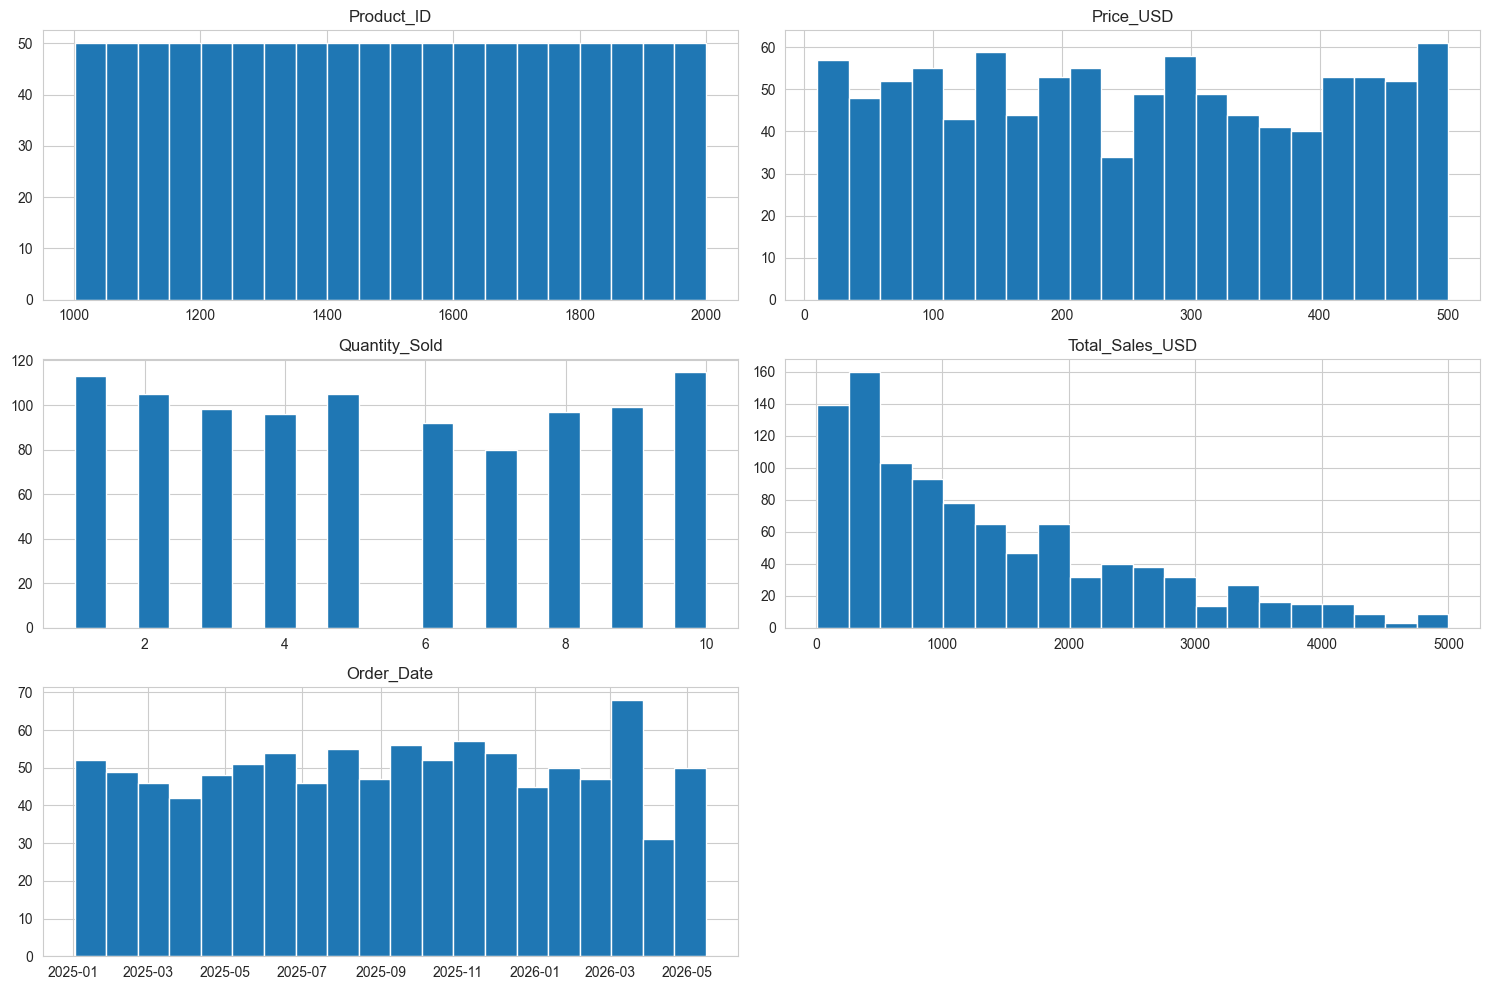

In [47]:
# Distribution plot for numerical columns

df.hist(figsize=(15,10), bins=20)

plt.tight_layout()
plt.show()

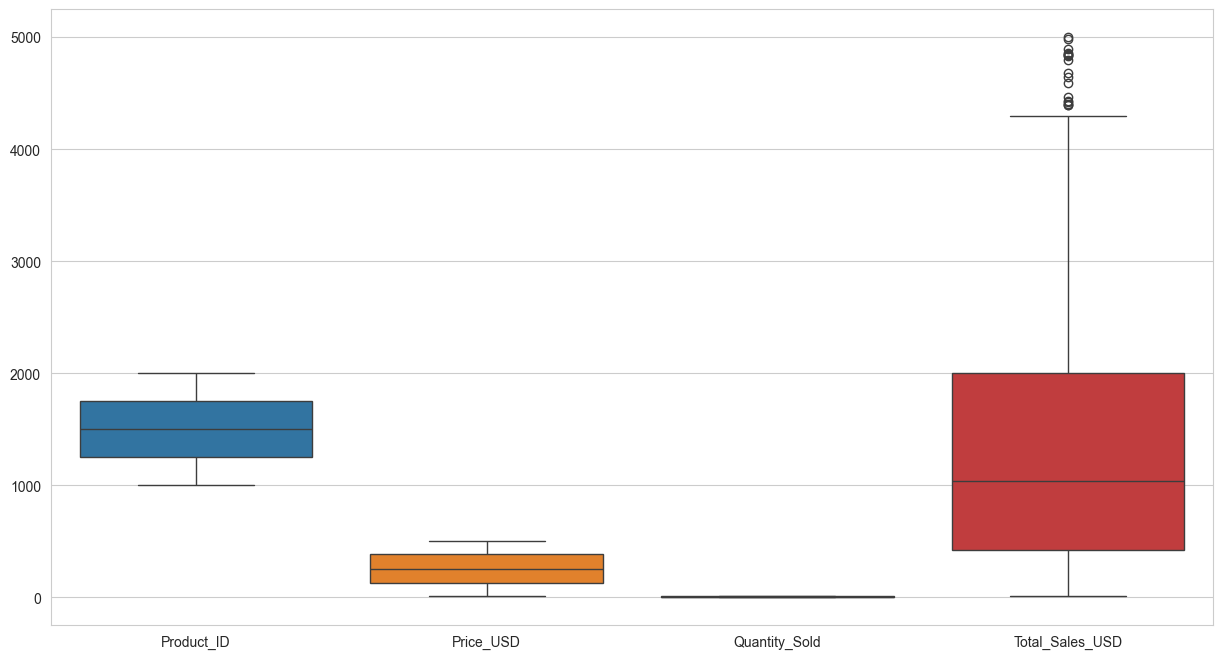

In [48]:
# Boxplot for numerical columns

plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=0)
plt.show()

In [49]:
# Correlation between numerical columns
correlation = df.corr(numeric_only=True)

correlation

,Product_ID,Price_USD,Quantity_Sold,Total_Sales_USD
Product_ID,1.000000,-0.004138,0.022511,0.003439
Price_USD,-0.004138,1.000000,-0.030791,0.665781
Quantity_Sold,0.022511,-0.030791,1.000000,0.625311
Total_Sales_USD,0.003439,0.665781,0.625311,1.000000


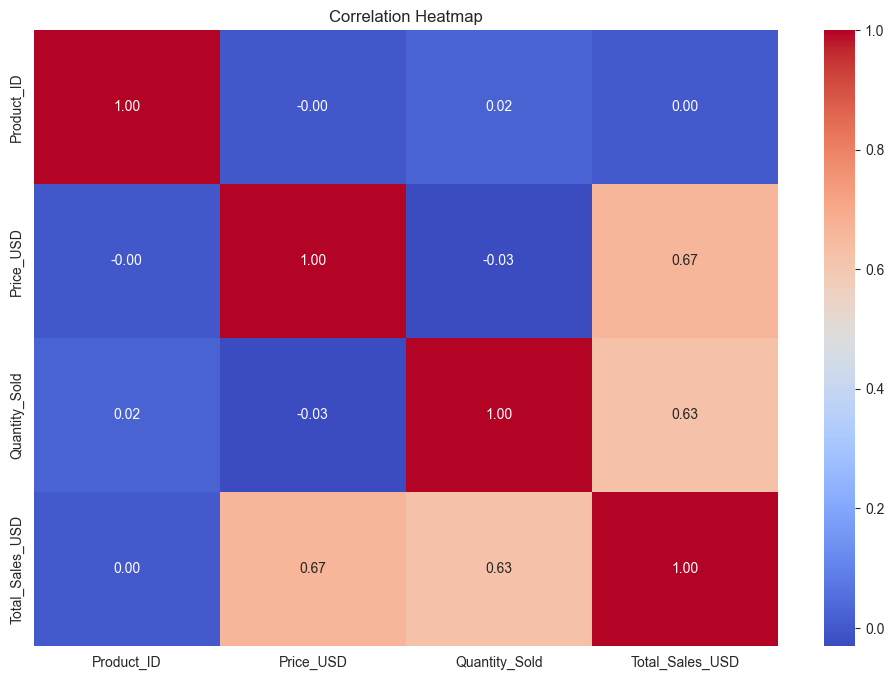

In [50]:
# Correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

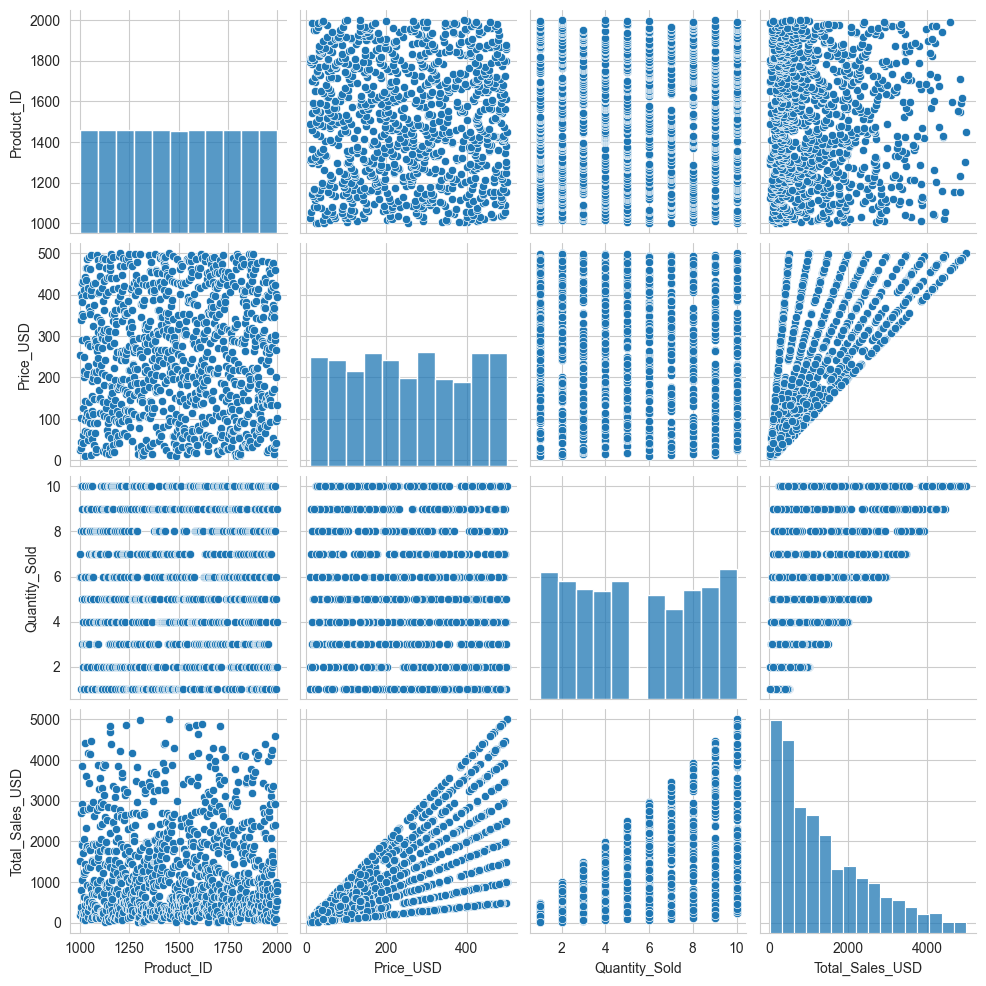

In [51]:
# Pairplot for relationships between variables

sns.pairplot(df)

plt.show()

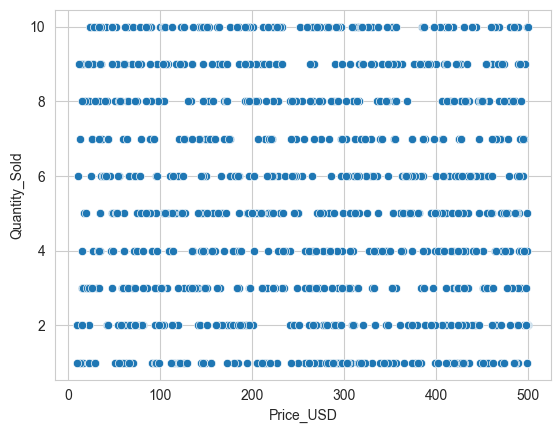

In [52]:
# Scatterplot

sns.scatterplot(
    x='Price_USD',
    y='Quantity_Sold',
    data=df
)

plt.show()

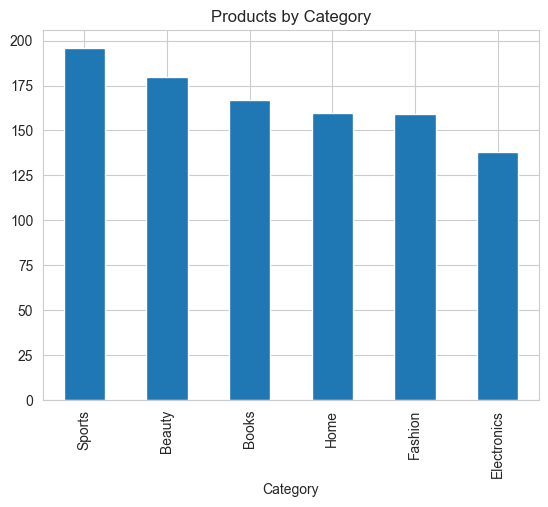

In [53]:
# bar chart

df['Category'].value_counts().plot(kind='bar')

plt.title('Products by Category')
plt.show()

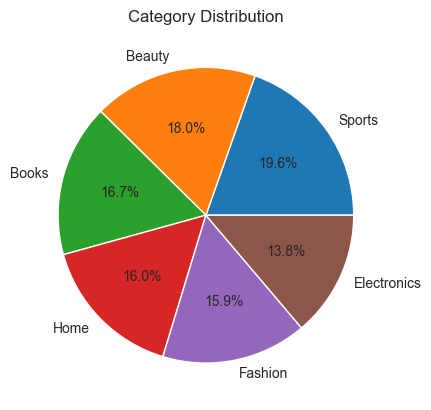

In [54]:
# pie chart

df['Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Category Distribution')
plt.savefig("images/category_distribution_percentage.png", dpi=300, bbox_inches='tight')
plt.show()

In [55]:
# ==========================================
# REVENUE PERCENTAGE BY CATEGORY
# ==========================================

# Calculate revenue by category
category_summary = (
    df.groupby('Category')['Total_Sales_USD']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Calculate percentage contribution
total_revenue = category_summary['Total_Sales_USD'].sum()

category_summary['Revenue_Percentage'] = (
    category_summary['Total_Sales_USD'] / total_revenue * 100
).round(2)

# Rename columns for better readability
category_summary.columns = [
    'Category',
    'Revenue (USD)',
    'Revenue (%)'
]

# Display the table
display(category_summary)

,Category,Revenue (USD),Revenue (%)
0,Sports,310674,22.66
1,Beauty,249665,18.21
2,Home,233891,17.06
3,Books,202704,14.78
4,Fashion,200854,14.65
5,Electronics,173244,12.64


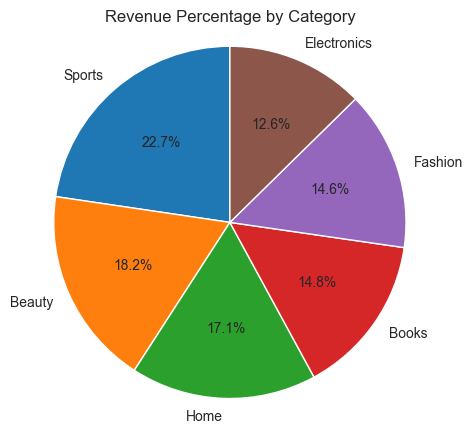

In [56]:
# ==========================================
# PIE CHART - REVENUE SHARE BY CATEGORY
# ==========================================

plt.figure(figsize=(5,5))

plt.pie(
    category_summary['Revenue (%)'],
    labels=category_summary['Category'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Revenue Percentage by Category")

plt.axis('equal')
plt.savefig("images/category_revenue_percentage.png", dpi=300, bbox_inches='tight')
plt.show()

In [57]:
# Convert categorical data into numerical

label_encoder = LabelEncoder()

df['Price_USD'] = label_encoder.fit_transform(df['Price_USD'])

## Top 10 Products by Revenue

This chart identifies the products generating the highest revenue.

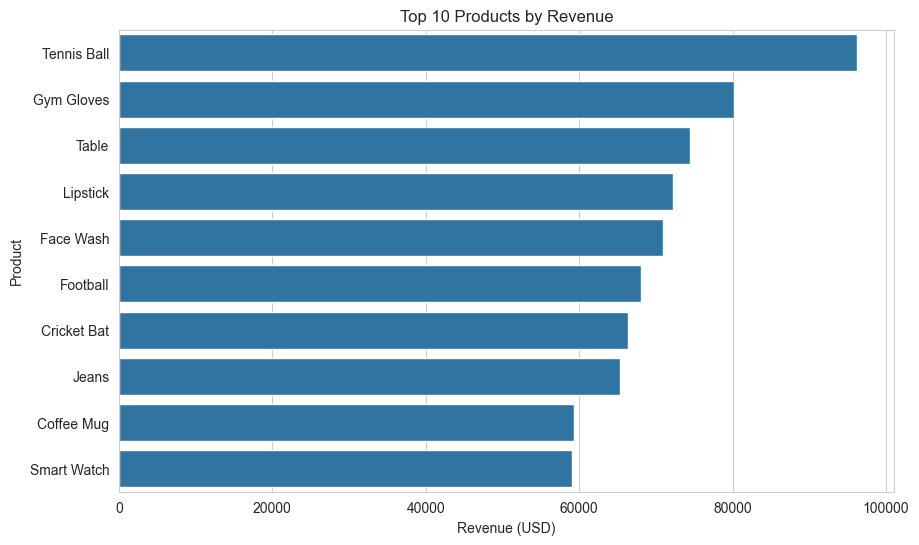

In [58]:
# ==========================================
# TOP 10 PRODUCTS BY REVENUE
# ==========================================

top_revenue_products = (
    df.groupby('Product_Name')['Total_Sales_USD']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_revenue_products.values,
    y=top_revenue_products.index
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (USD)')
plt.ylabel('Product')
plt.savefig("images/top_10_product_by_revenue.png", dpi=300, bbox_inches='tight')
plt.show()

## Top 10 Products by Quantity Sold

This chart identifies the products with the highest sales volume.

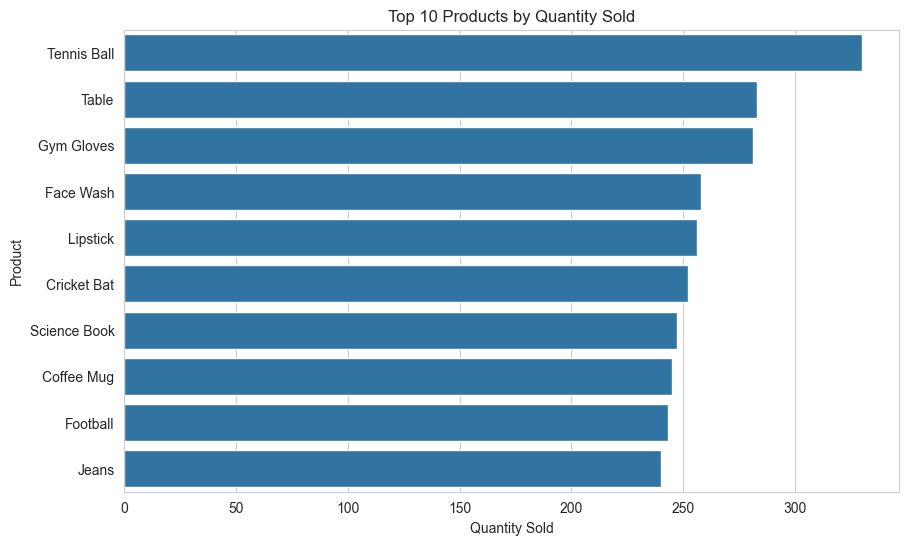

In [59]:
# ==========================================
# TOP 10 PRODUCTS BY QUANTITY SOLD
# ==========================================

top_quantity_products = (
    df.groupby('Product_Name')['Quantity_Sold']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_quantity_products.values,
    y=top_quantity_products.index
)

plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.savefig("images/top_10_product_by_quantity_sold.png", dpi=300, bbox_inches='tight')
plt.show()

## Revenue by Category

This visualization compares the total revenue generated by each product category.

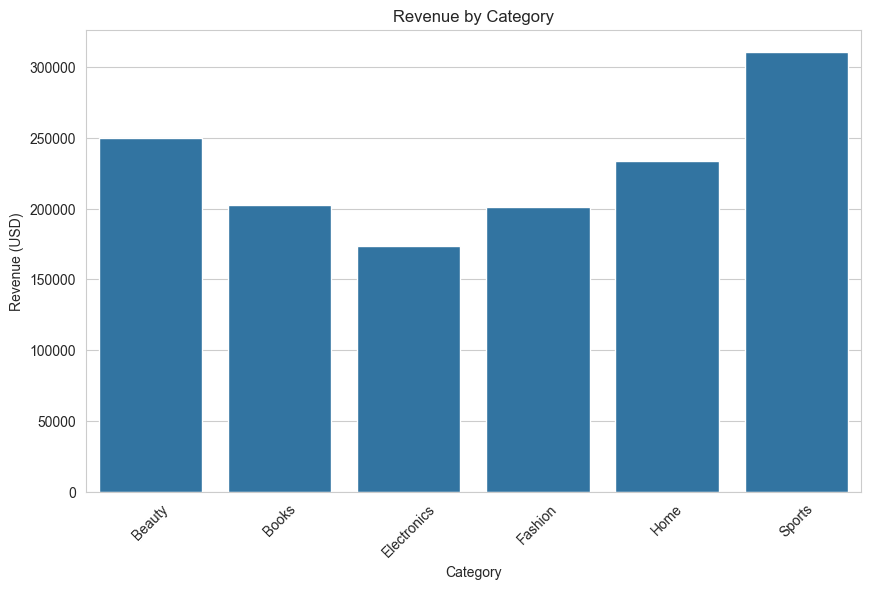

In [60]:
# ==========================================
# CATEGORY REVENUE ANALYSIS
# ==========================================

category_sales = (
    df.groupby('Category')['Total_Sales_USD']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue (USD)')

plt.xticks(rotation=45)
plt.savefig("images/category_revenue.png", dpi=300, bbox_inches='tight')
plt.show()

## Revenue by Customer City

This visualization compares total revenue generated from different customer cities.

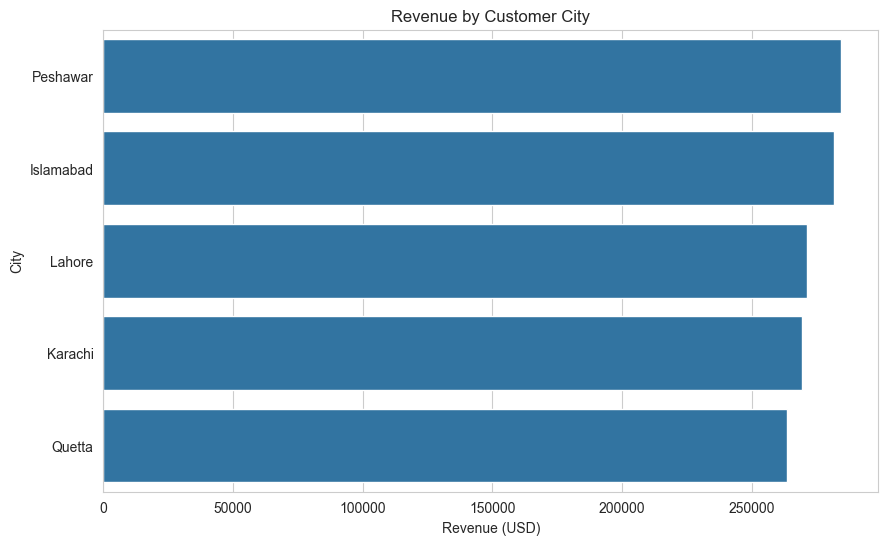

In [61]:
# ==========================================
# CITY-WISE REVENUE ANALYSIS
# ==========================================

city_sales = (
    df.groupby('Customer_City')['Total_Sales_USD']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=city_sales.values,
    y=city_sales.index
)

plt.title('Revenue by Customer City')
plt.xlabel('Revenue (USD)')
plt.ylabel('City')
plt.savefig("images/city_wise_revenue.png", dpi=300, bbox_inches='tight')
plt.show()

## Monthly Revenue Trend

This visualization shows how revenue changes throughout the year.

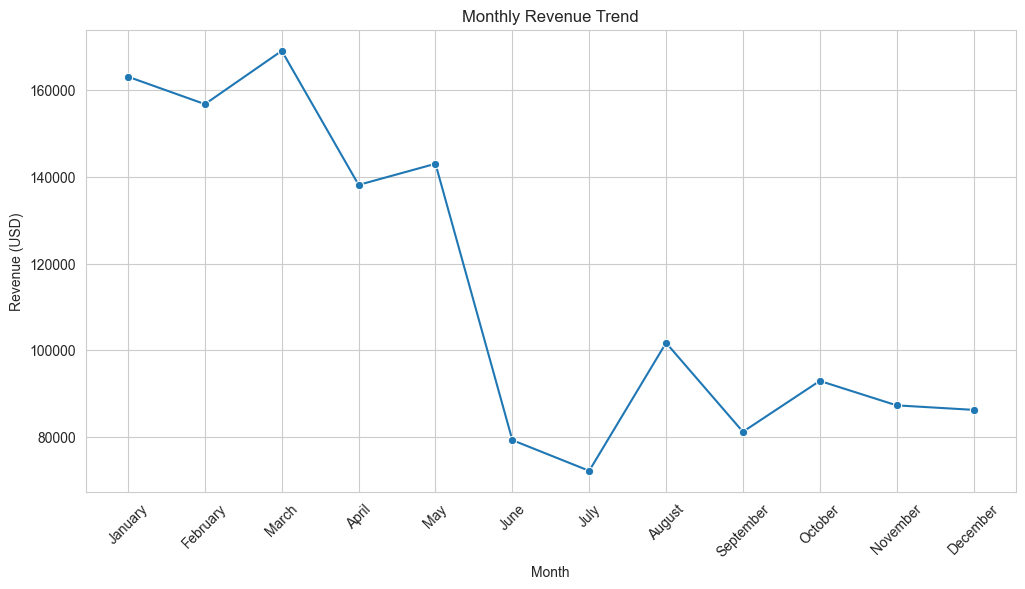

In [62]:
# ==========================================
# MONTHLY REVENUE TREND
# ==========================================

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df['Month'] = df['Order_Date'].dt.month_name()

monthly_revenue = (
    df.groupby('Month')['Total_Sales_USD']
    .sum()
)

month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_revenue = monthly_revenue.reindex(month_order)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (USD)')

plt.xticks(rotation=45)
plt.savefig("images/monthly_revenue_trend.png", dpi=300, bbox_inches='tight')
plt.show()

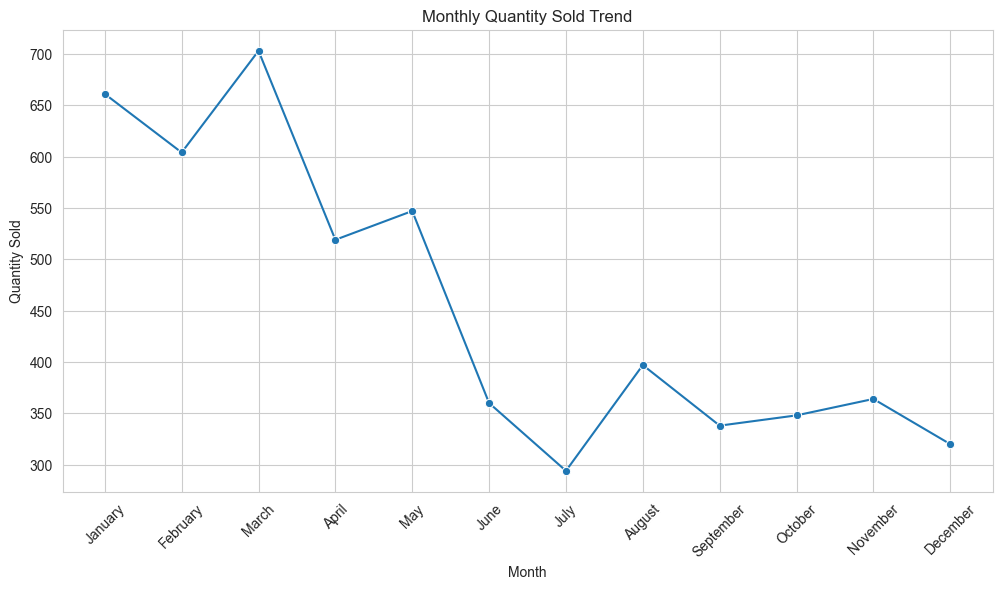

In [63]:
# ==========================================
# MONTHLY QUANTITY SOLD TREND
# ==========================================

monthly_quantity = (
    df.groupby('Month')['Quantity_Sold']
    .sum()
)

monthly_quantity = monthly_quantity.reindex(month_order)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_quantity.index,
    y=monthly_quantity.values,
    marker='o'
)

plt.title('Monthly Quantity Sold Trend')
plt.xlabel('Month')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=45)
plt.savefig("images/monthly_sales_trend.png", dpi=300, bbox_inches='tight')
plt.show()

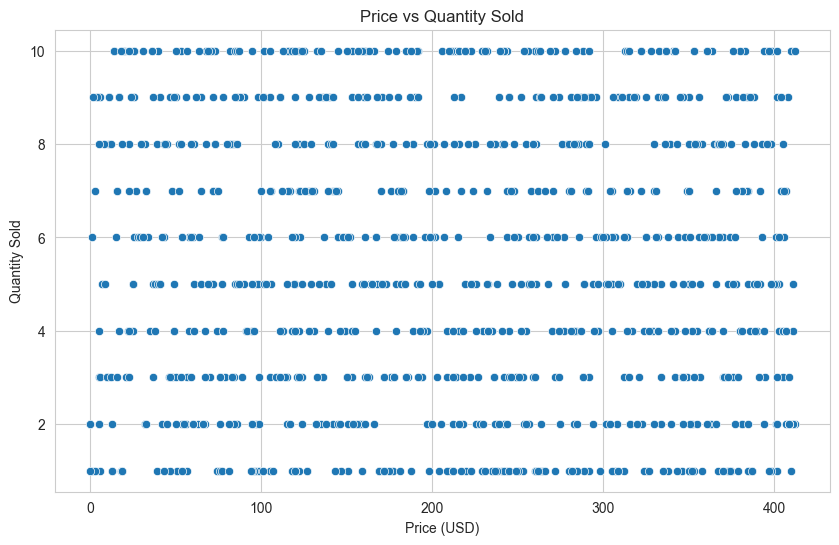

In [64]:
# ==========================================
# PRICE VS QUANTITY SOLD
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Price_USD',
    y='Quantity_Sold'
)

plt.title('Price vs Quantity Sold')
plt.xlabel('Price (USD)')
plt.ylabel('Quantity Sold')

plt.show()

## Correlation Analysis

The correlation heatmap illustrates the relationship between numerical variables in the dataset.

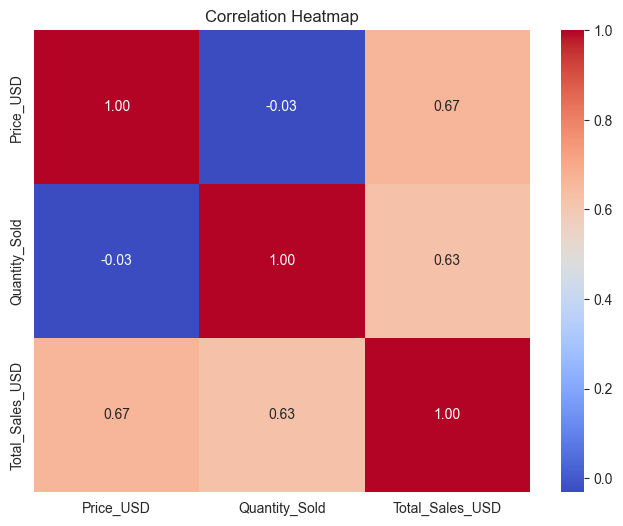

In [65]:
# ==========================================
# CORRELATION HEATMAP
# ==========================================

numeric_df = df[
    ['Price_USD',
     'Quantity_Sold',
     'Total_Sales_USD']
]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [66]:
# ==========================================
# TOP 5 PRODUCTS
# ==========================================

top5 = (
    df.groupby('Product_Name')['Total_Sales_USD']
    .sum()
    .sort_values(ascending=False)
    .head()
)

print("Top 5 Products by Revenue")
print(top5)

Top 5 Products by Revenue
Product_Name
Tennis Ball    96227
Gym Gloves     80127
Table          74455
Lipstick       72172
Face Wash      70936
Name: Total_Sales_USD, dtype: int64


In [67]:
# ==========================================
# BOTTOM 5 PRODUCTS
# ==========================================

bottom5 = (
    df.groupby('Product_Name')['Total_Sales_USD']
    .sum()
    .sort_values()
    .head()
)

print("Bottom 5 Products by Revenue")
print(bottom5)

Bottom 5 Products by Revenue
Product_Name
Keyboard      25372
Jacket        39583
Headphones    42047
Chair         44994
T-Shirt       46535
Name: Total_Sales_USD, dtype: int64


In [68]:
# KPI SUMMARY

print("Total Revenue: $", df['Total_Sales_USD'].sum())
print("Total Quantity Sold:", df['Quantity_Sold'].sum())
print("Average Product Price: $", round(df['Price_USD'].mean(),2))
print("Number of Products:", df['Product_Name'].nunique())
print("Number of Cities:", df['Customer_City'].nunique())

Total Revenue: $ 1371032
Total Quantity Sold: 5455
Average Product Price: $ 207.68
Number of Products: 24
Number of Cities: 5


# Business Insights

The following insights summarize the major findings obtained from the analysis.

# Results & Business Insights

## 1. Revenue by Category

The category-wise revenue analysis indicates noticeable differences in sales performance across product categories.

### Key Findings
- **Sports** generated the highest revenue among all categories, making it the strongest-performing business segment.
- **Beauty** and **Home** categories also contributed significantly to overall revenue.
- **Books** and **Fashion** showed moderate sales performance.
- **Electronics** generated the lowest revenue, indicating relatively weaker customer demand or lower sales volume.

### Business Recommendation
- Increase inventory and promotional efforts for the **Sports** category.
- Review pricing, marketing strategy, and product assortment for **Electronics** to improve performance.

---

## 2. Revenue by Customer City

The city-wise sales analysis reveals that revenue is fairly balanced across all customer locations.

### Key Findings
- **Peshawar** generated the highest overall revenue.
- **Islamabad** followed closely behind.
- **Quetta** recorded the lowest revenue among the analyzed cities.
- The small variation between cities suggests that customer demand is well distributed geographically.

### Business Recommendation
- Maintain strong inventory levels across all cities.
- Conduct targeted promotional campaigns in lower-performing cities such as **Quetta** to increase sales.

---

## 3. Monthly Revenue Trend

The monthly revenue trend highlights fluctuations in customer purchasing behavior throughout the year.

### Key Findings
- Revenue reached its highest level in **March**.
- Sales remained strong during **January**, **February**, and **May**.
- A significant decline occurred in **June**, reaching the lowest point around **July**.
- Revenue recovered during **August**, followed by relatively stable performance during the remaining months.

### Business Recommendation
- Investigate the reasons behind the decline in **June** and **July**.
- Plan marketing campaigns before the mid-year slowdown.
- Increase inventory during the high-performing months to maximize revenue.

---

## 4. Top 10 Products by Quantity Sold

This analysis identifies the products with the highest customer demand.

### Key Findings
- **Tennis Ball** recorded the highest quantity sold.
- **Table** and **Gym Gloves** also experienced strong sales volume.
- **Lipstick**, **Face Wash**, and **Cricket Bat** consistently ranked among the best-selling products.
- Demand is spread across multiple categories, indicating a diversified customer preference.

### Business Recommendation
- Ensure adequate inventory for high-demand products.
- Bundle popular products with lower-selling items to increase overall sales.

---

## 5. Top 10 Products by Revenue

Revenue analysis identifies the products generating the greatest financial return.

### Key Findings
- **Tennis Ball** generated the highest revenue.
- **Gym Gloves** ranked second in revenue generation.
- **Table** and **Lipstick** were also among the top revenue contributors.
- **Smart Watch** entered the top revenue list despite not appearing among the highest-selling products by quantity, suggesting a higher selling price.

### Business Recommendation
- Prioritize premium and high-revenue products in marketing campaigns.
- Focus on both sales volume and product profitability when making inventory decisions.

---

# Overall Business Insights

- Sports is the most profitable product category.
- Customer demand is relatively balanced across all cities.
- March is the strongest sales month, while June and July show a noticeable decline.
- Tennis Ball is both the highest-selling and highest revenue-generating product.
- Some premium products generate substantial revenue despite lower sales volume, highlighting the importance of pricing strategy.
- Data-driven inventory planning and seasonal marketing campaigns can further improve business performance.

# Conclusion

This project analyzed retail sales data using Python, Pandas, Matplotlib, and Seaborn. The analysis identified top-performing products, category-wise revenue, customer demand across cities, and monthly sales trends. The insights generated from this project can support inventory planning, pricing strategies, and business decision-making.